# Customer Churn & Retention Analytics
## Notebook 2: Churn Deep Dive Analysis

### Objective

This notebook investigates the major factors associated with customer churn.

The analysis focuses on:
- Demographics
- Customer tenure
- Customer satisfaction
- Complaints
- Ordering behavior
- Cashback and coupon usage
- Customer engagement
- Cross-segment churn patterns
- Statistical significance

The target variable is:

- **Churn = 1:** Churned customer
- **Churn = 0:** Retained customer

No machine learning models are used. This is a pure business and statistical analysis notebook.

In [1]:
# Import libraries required for churn deep-dive analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Import statistical testing functionality
from scipy.stats import ttest_ind

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set pandas display options for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Set a professional visualization style
sns.set_theme(style="whitegrid", context="notebook")

# Define project color scheme
CHURN_COLOR = "#E74C3C"
RETAINED_COLOR = "#2ECC71"

# Define input and output paths
CLEANED_FILE_PATH = "../data/cleaned/cleaned_ecommerce_churn.csv"
IMAGE_FOLDER = "../reports/images"

# Create output directory if it does not already exist
import os
os.makedirs(IMAGE_FOLDER, exist_ok=True)

# Print notebook information
print("Customer Churn & Retention Analytics")
print("Notebook 2: Churn Deep Dive Analysis")
print("=" * 55)

Customer Churn & Retention Analytics
Notebook 2: Churn Deep Dive Analysis


## Load Cleaned Dataset

The cleaned CSV generated in Notebook 1 is loaded here.

No missing-value treatment is performed because the dataset has already been cleaned.
We only perform a quick structural validation before beginning the analysis.

In [2]:
# Load the cleaned customer churn dataset
df = pd.read_csv(CLEANED_FILE_PATH)

# Display basic dataset dimensions
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

# Verify that no missing values remain
total_missing_values = df.isna().sum().sum()

print(f"Total Missing Values: {total_missing_values:,}")

# Verify the churn distribution
print("\nChurn Distribution:")
print(df["Churn"].value_counts().sort_index())

Rows    : 5,630
Columns : 22
Total Missing Values: 0

Churn Distribution:
Churn
0    4682
1     948
Name: count, dtype: int64


### Business Insight

The dataset should contain approximately 5,630 customers with 948 churned customers.

This notebook will use the overall churn rate as the baseline. Every segment-specific
churn rate will be compared against this baseline to identify potentially high-risk
customer groups.

## Section 2: Churn Rate by Demographics

Customer churn can vary significantly across customer segments.

To make the analysis reusable, the following function:
1. Calculates retained and churned customer counts.
2. Calculates churn rate for every category.
3. Creates a count comparison chart.
4. Creates a churn-rate comparison chart.

This same function is then applied to multiple demographic and behavioral
categorical variables.

In [3]:
def analyze_categorical_churn(dataframe, column_name):
    """
    Analyze customer churn across categories of a categorical variable.

    The function calculates:
    - Retained customer count
    - Churned customer count
    - Churn rate
    - Overall segment distribution

    It also creates a two-panel visualization.
    """

    # Create a cross-tabulation of churn counts by category
    count_table = pd.crosstab(
        dataframe[column_name],
        dataframe["Churn"]
    )

    # Ensure both churn categories exist in the table
    count_table = count_table.reindex(
        columns=[0, 1],
        fill_value=0
    )

    # Rename churn columns for readability
    count_table.columns = ["Retained", "Churned"]

    # Calculate churn rate for each category
    churn_rate_table = (
        count_table["Churned"] /
        count_table.sum(axis=1) * 100
    ).sort_values(ascending=False)

    # Create summary dataframe
    analysis_table = count_table.copy()
    analysis_table["Total Customers"] = (
        analysis_table["Retained"] +
        analysis_table["Churned"]
    )
    analysis_table["Churn Rate %"] = churn_rate_table

    # Print analysis table
    print(f"\nChurn Analysis by {column_name}")
    print("=" * 60)
    display(analysis_table.sort_values("Churn Rate %", ascending=False))

    # Create two-panel figure
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6)
    )

    # ---------------- Count comparison ----------------
    count_table.plot(
        kind="bar",
        ax=axes[0],
        color=[RETAINED_COLOR, CHURN_COLOR]
    )

    axes[0].set_title(
        f"Customer Count by {column_name}",
        fontsize=14,
        fontweight="bold"
    )
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel("Number of Customers")
    axes[0].tick_params(axis="x", rotation=30)

    # Add count labels to bars
    for container in axes[0].containers:
        axes[0].bar_label(
            container,
            fmt="%d",
            padding=3
        )

    # ---------------- Churn rate ----------------
    churn_bars = axes[1].bar(
        churn_rate_table.index.astype(str),
        churn_rate_table.values,
        color=CHURN_COLOR
    )

    axes[1].set_title(
        f"Churn Rate by {column_name}",
        fontsize=14,
        fontweight="bold"
    )
    axes[1].set_xlabel(column_name)
    axes[1].set_ylabel("Churn Rate (%)")

    # Add churn-rate labels
    for bar in churn_bars:
        height = bar.get_height()

        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    # Add overall churn rate reference line
    overall_churn_rate = dataframe["Churn"].mean() * 100

    axes[1].axhline(
        overall_churn_rate,
        linestyle="--",
        linewidth=2,
        color="#3498DB",
        label=f"Overall Churn: {overall_churn_rate:.1f}%"
    )

    axes[1].legend()

    # Add overall title
    fig.suptitle(
        f"Churn Analysis by {column_name}",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()

    # Create safe filename
    safe_column_name = column_name.lower().replace(" ", "_")

    # Save visualization
    plt.savefig(
        f"{IMAGE_FOLDER}/churn_by_{safe_column_name}.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    return analysis_table

### Gender Churn Analysis

Gender is analyzed to determine whether churn is concentrated more heavily
among male or female customers.

The important comparison is not simply customer volume, but the **churn rate**
within each gender.


Churn Analysis by Gender


,Retained,Churned,Total Customers,Churn Rate %
Gender,,,,
Male,2784,600,3384,17.73
Female,1898,348,2246,15.49


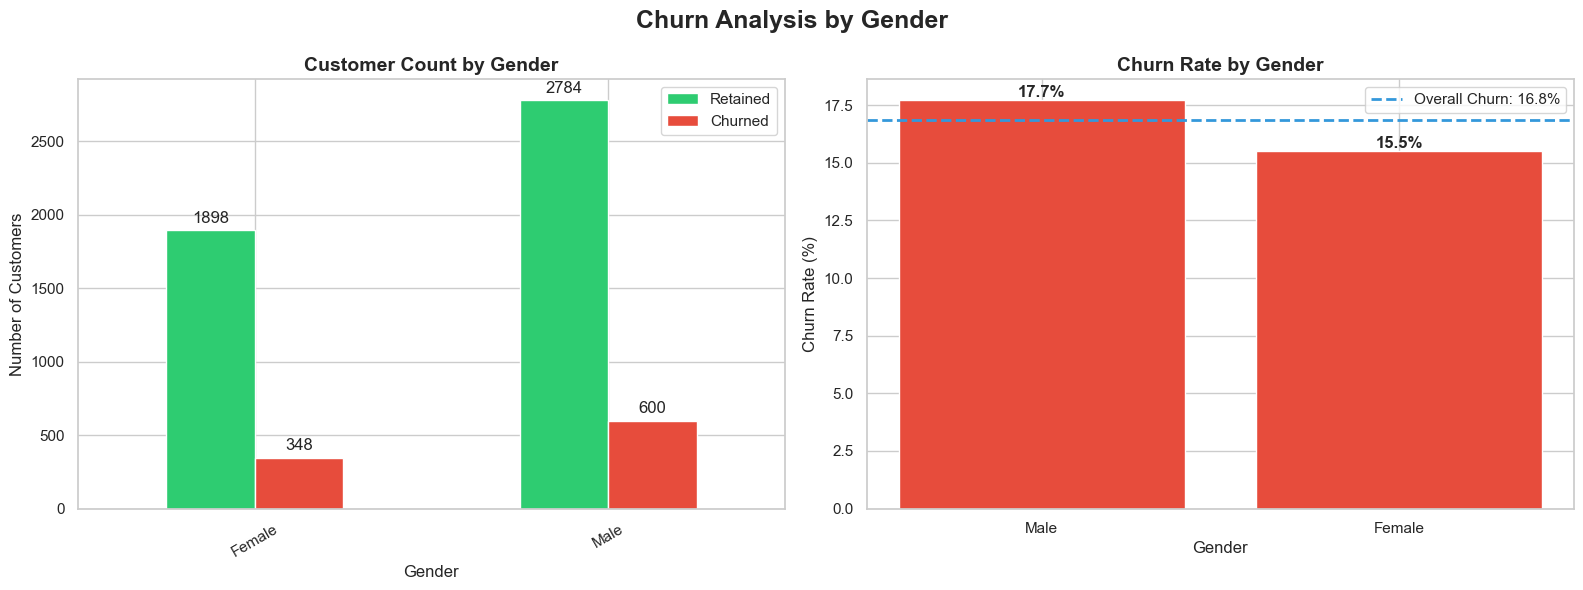

In [4]:
# Analyze churn by gender
gender_churn_analysis = analyze_categorical_churn(
    df,
    "Gender"
)

### Marital Status and City Tier

Marital status and city tier may represent differences in customer lifestyle,
purchasing behavior, accessibility, and geographic market characteristics.

These segments are analyzed to identify whether any category has a materially
higher churn rate than the overall customer base.


Churn Analysis by MaritalStatus


,Retained,Churned,Total Customers,Churn Rate %
MaritalStatus,,,,
Single,1316,480,1796,26.73
Divorced,724,124,848,14.62
Married,2642,344,2986,11.52


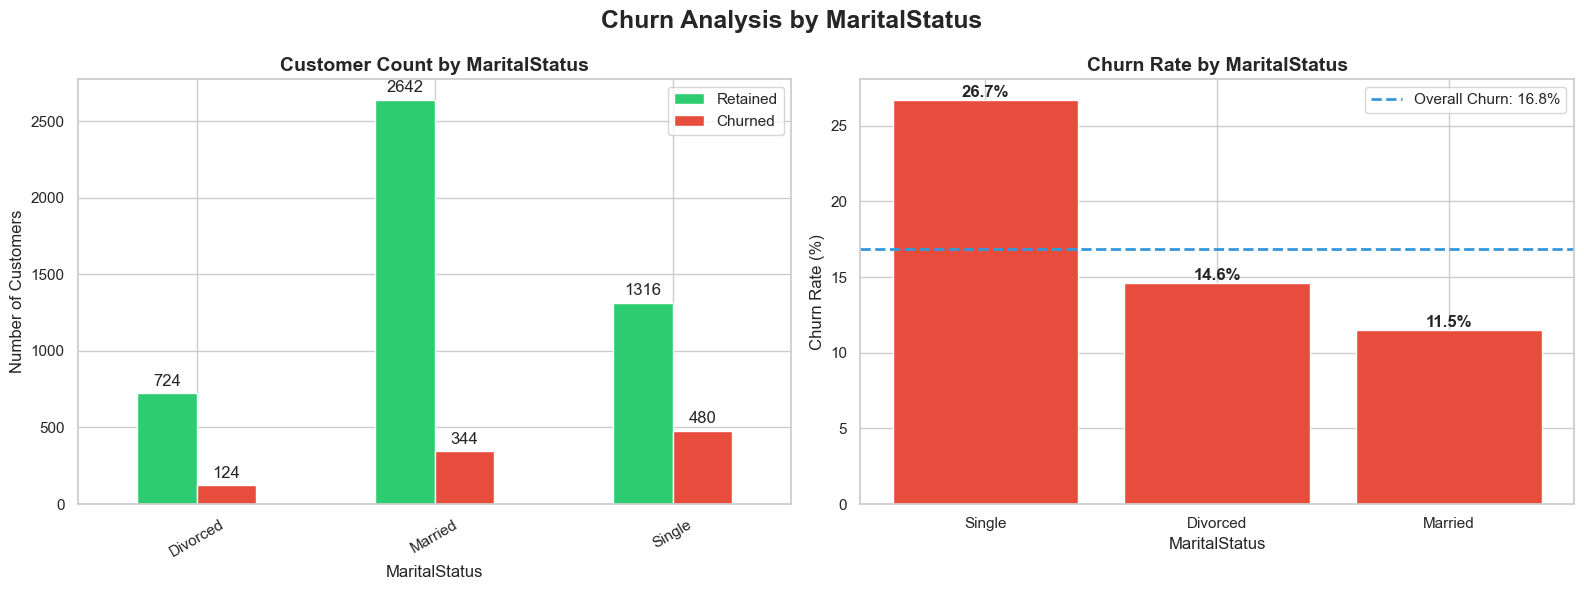


Churn Analysis by CityTier


,Retained,Churned,Total Customers,Churn Rate %
CityTier,,,,
3,1354,368,1722,21.37
2,194,48,242,19.83
1,3134,532,3666,14.51


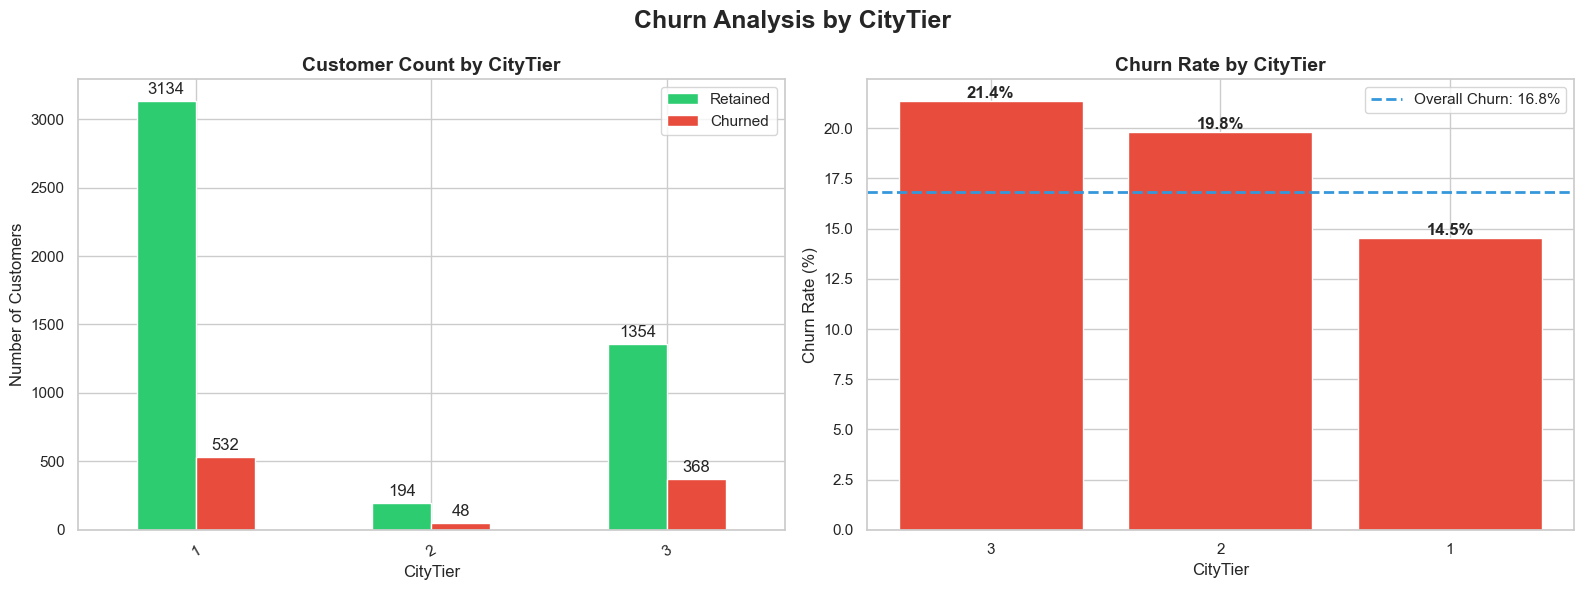

In [5]:
# Analyze churn by marital status
marital_status_churn_analysis = analyze_categorical_churn(
    df,
    "MaritalStatus"
)

# Analyze churn by city tier
city_tier_churn_analysis = analyze_categorical_churn(
    df,
    "CityTier"
)

### Digital and Product Preferences

Login device, payment mode, and preferred order category can reveal differences
in the customer experience.

A segment with a high churn rate may indicate a potential UX, payment,
merchandising, or product-category retention opportunity.


Churn Analysis by PreferredLoginDevice


,Retained,Churned,Total Customers,Churn Rate %
PreferredLoginDevice,,,,
Phone,955,276,1231,22.42
Computer,1310,324,1634,19.83
Mobile Phone,2417,348,2765,12.59


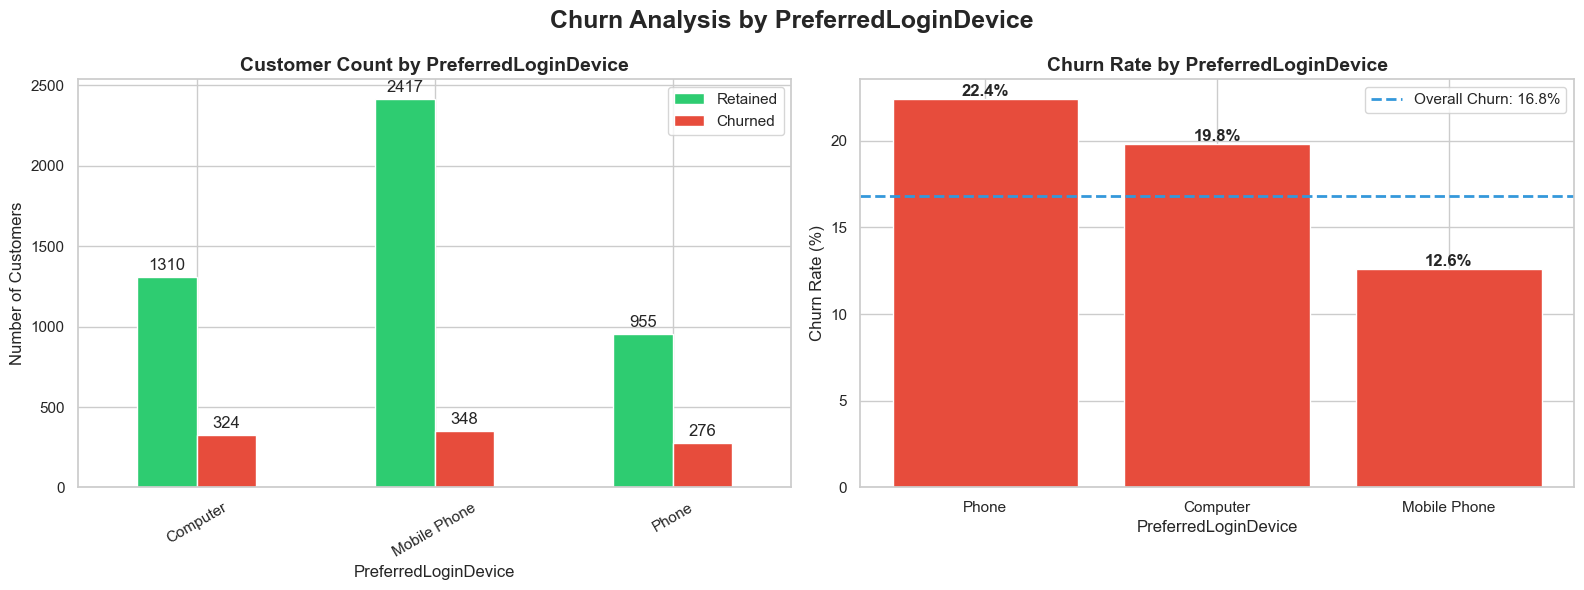


Churn Analysis by PreferredPaymentMode


,Retained,Churned,Total Customers,Churn Rate %
PreferredPaymentMode,,,,
Cash on Delivery,386,129,515,25.05
E wallet,474,140,614,22.80
CC,214,59,273,21.61
UPI,342,72,414,17.39
Debit Card,1958,355,2313,15.35
Credit Card,1308,193,1501,12.86


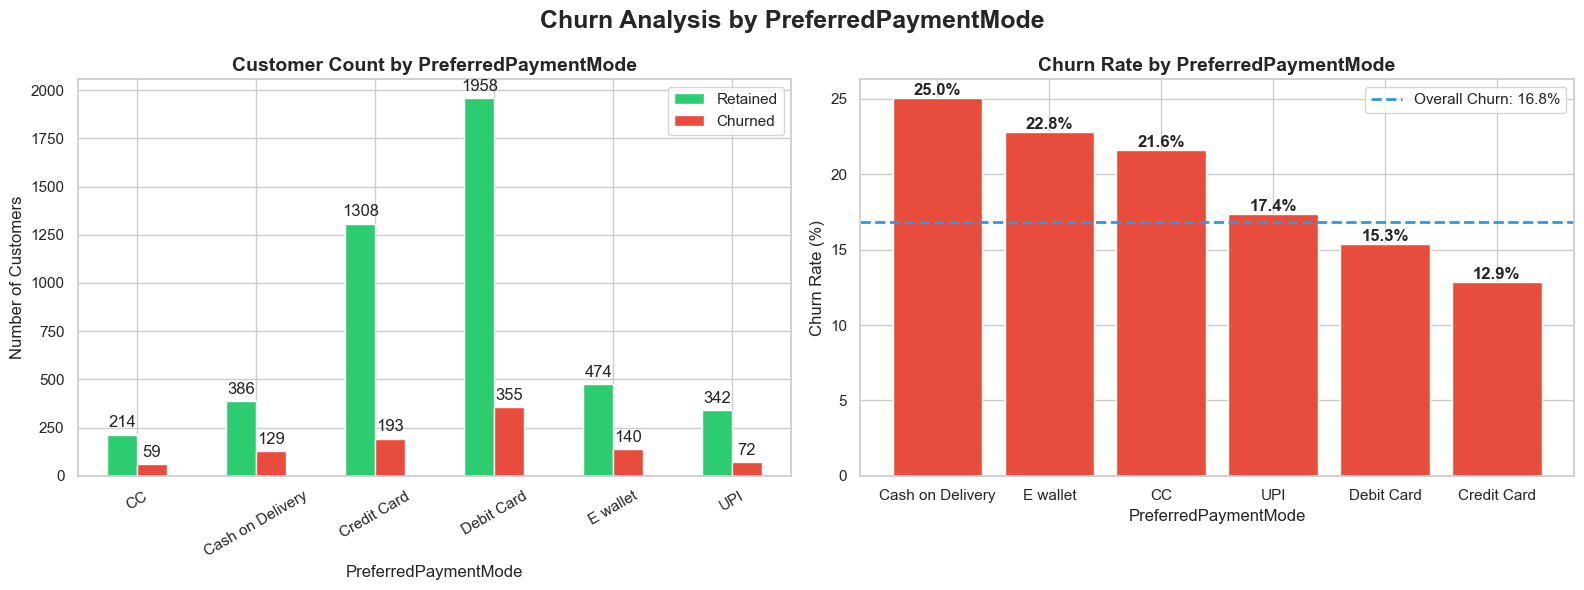


Churn Analysis by PreferedOrderCat


,Retained,Churned,Total Customers,Churn Rate %
PreferedOrderCat,,,,
Mobile,1510,570,2080,27.40
Fashion,698,128,826,15.50
Laptop & Accessory,1840,210,2050,10.24
Others,244,20,264,7.58
Grocery,390,20,410,4.88


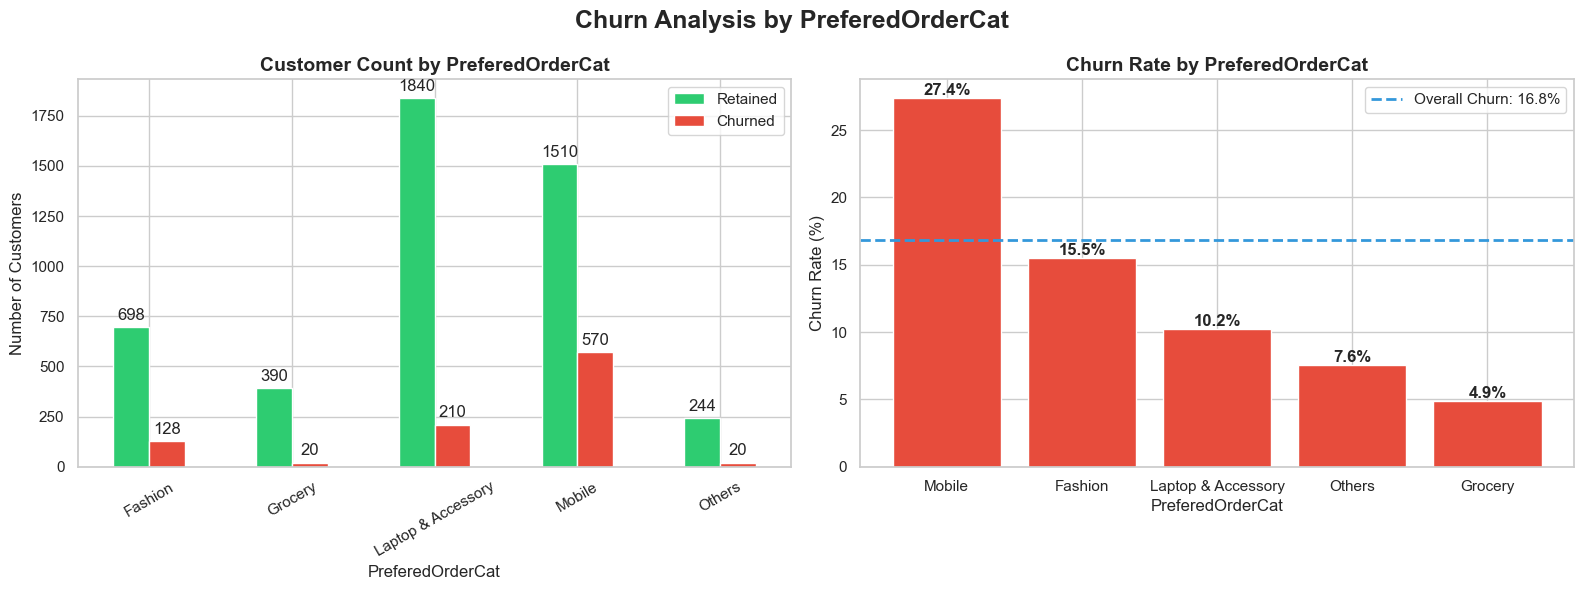

In [6]:
# Analyze churn by preferred login device
login_device_churn_analysis = analyze_categorical_churn(
    df,
    "PreferredLoginDevice"
)

# Analyze churn by preferred payment mode
payment_mode_churn_analysis = analyze_categorical_churn(
    df,
    "PreferredPaymentMode"
)

# Analyze churn by preferred order category
order_category_churn_analysis = analyze_categorical_churn(
    df,
    "PreferedOrderCat"
)

## Section 3: Churn Rate by Numerical Variables

Numerical customer behavior variables can reveal differences between churned
and retained customers.

For each variable we compare:
- Mean
- Median
- Distribution
- Potential outliers

The boxplots make it easier to see whether churned customers behave differently
from retained customers.


Tenure
-------------------------------------------------------
Retained - Mean   : 11.40
Retained - Median : 10.00
Churned  - Mean   : 3.86
Churned  - Median : 1.00


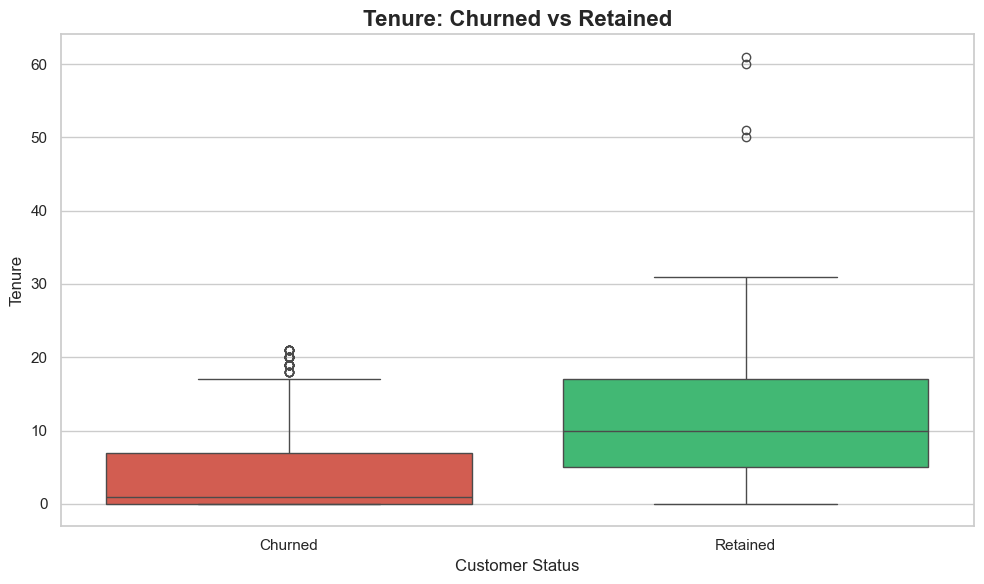


DaySinceLastOrder
-------------------------------------------------------
Retained - Mean   : 4.71
Retained - Median : 3.00
Churned  - Mean   : 3.22
Churned  - Median : 2.50


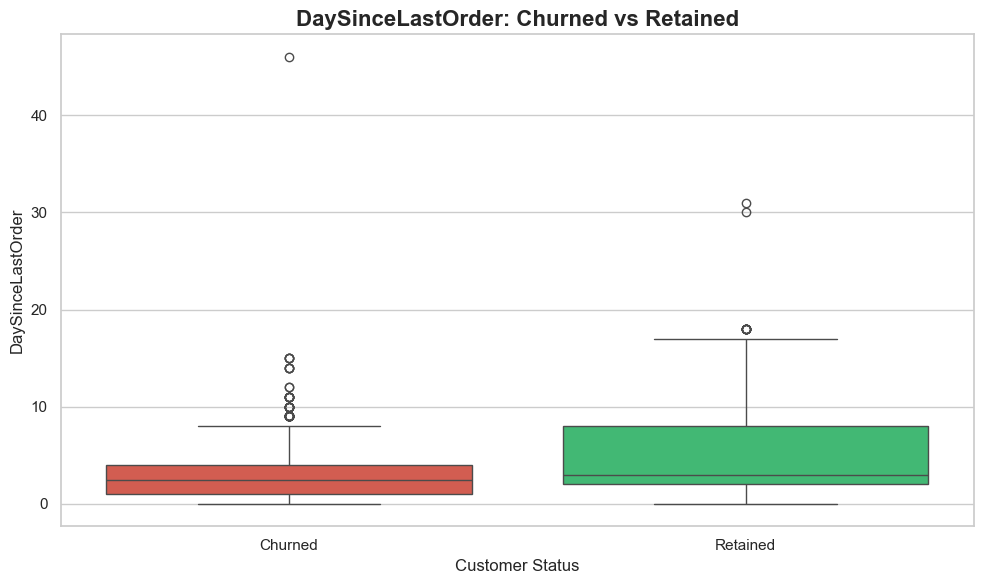


CashbackAmount
-------------------------------------------------------
Retained - Mean   : 180.64
Retained - Median : 166.12
Churned  - Mean   : 160.37
Churned  - Median : 149.66


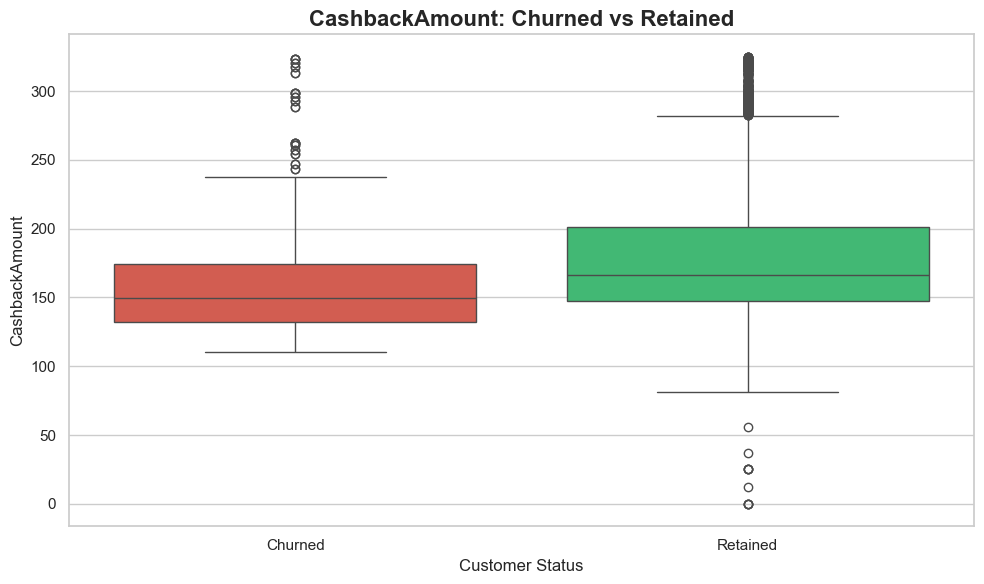


OrderCount
-------------------------------------------------------
Retained - Mean   : 2.99
Retained - Median : 2.00
Churned  - Mean   : 2.81
Churned  - Median : 2.00


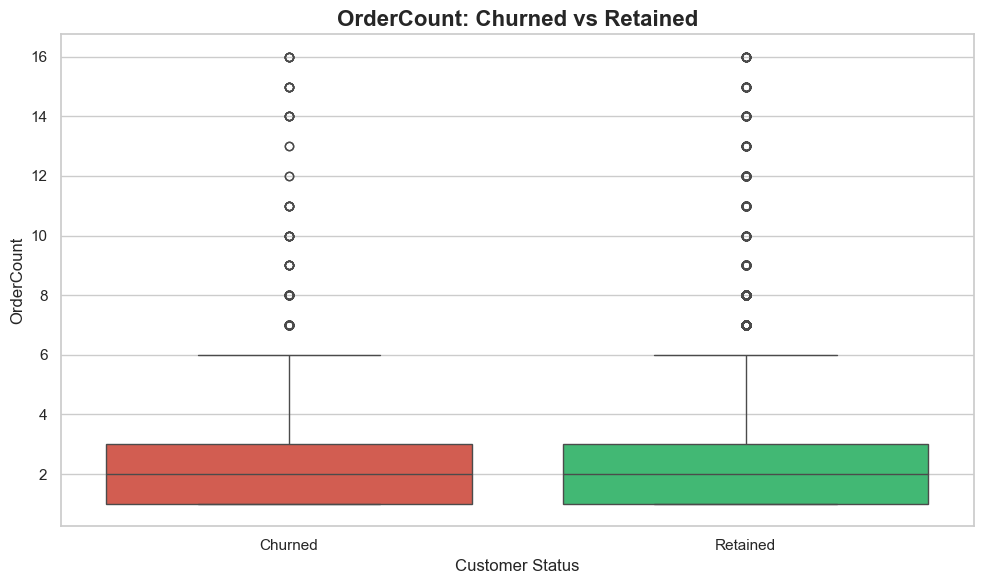


CouponUsed
-------------------------------------------------------
Retained - Mean   : 1.72
Retained - Median : 1.00
Churned  - Mean   : 1.71
Churned  - Median : 1.00


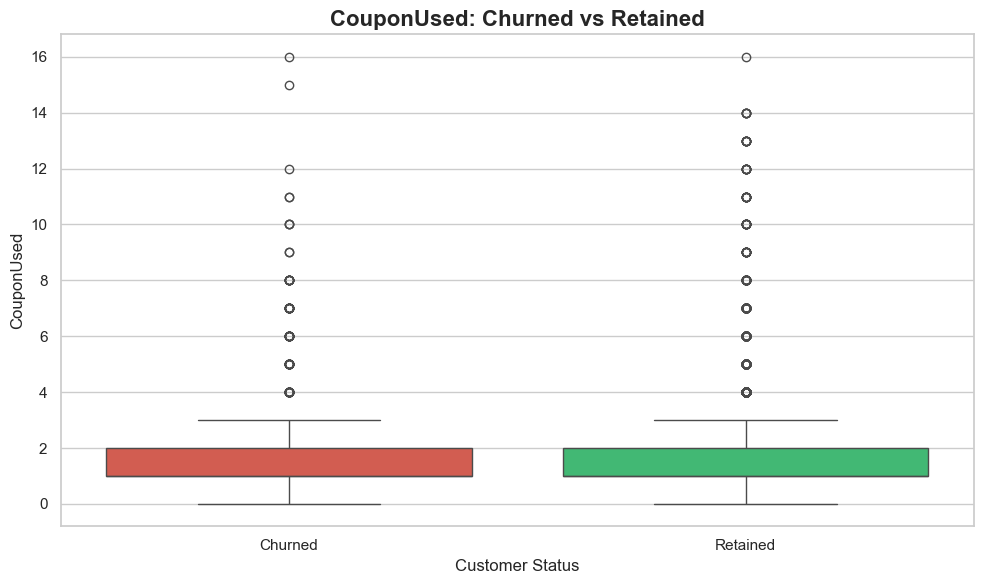


HourSpendOnApp
-------------------------------------------------------
Retained - Mean   : 2.93
Retained - Median : 3.00
Churned  - Mean   : 2.96
Churned  - Median : 3.00


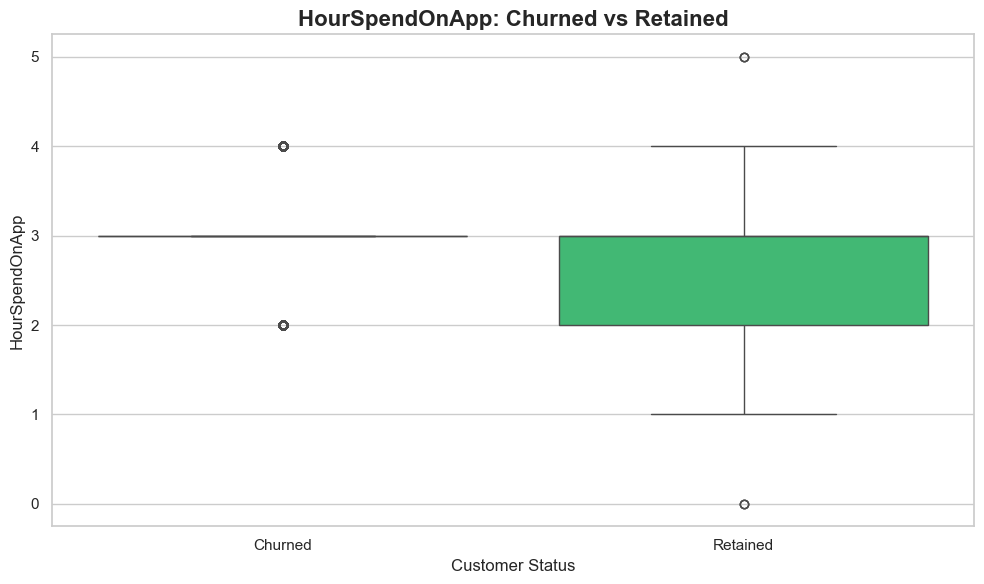


WarehouseToHome
-------------------------------------------------------
Retained - Mean   : 15.31
Retained - Median : 14.00
Churned  - Mean   : 16.86
Churned  - Median : 14.00


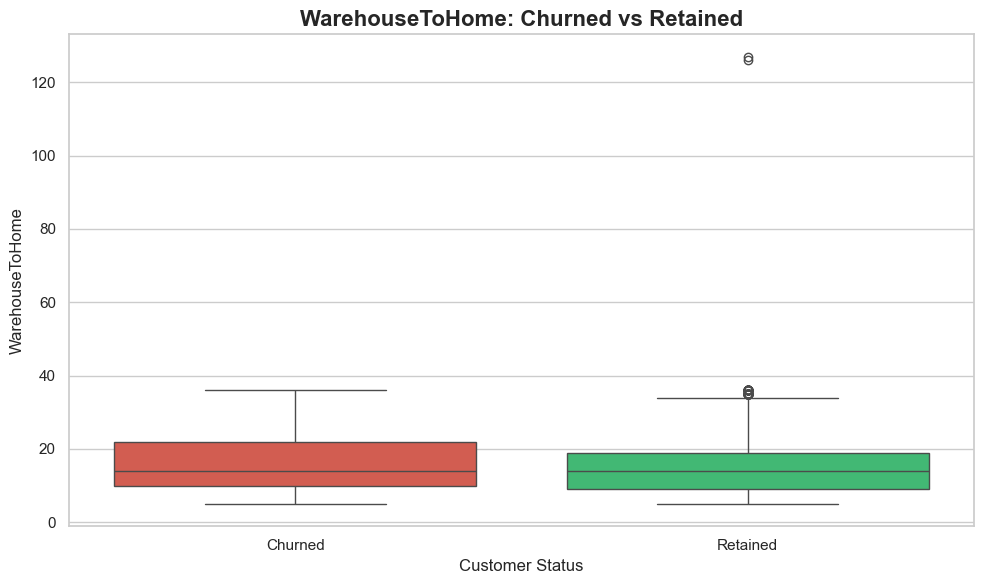

In [7]:
# Define numerical variables for churn comparison
numerical_churn_variables = [
    "Tenure",
    "DaySinceLastOrder",
    "CashbackAmount",
    "OrderCount",
    "CouponUsed",
    "HourSpendOnApp",
    "WarehouseToHome"
]

# Loop through each numerical variable
for column in numerical_churn_variables:

    # Calculate mean and median for retained customers
    retained_mean = df.loc[df["Churn"] == 0, column].mean()
    retained_median = df.loc[df["Churn"] == 0, column].median()

    # Calculate mean and median for churned customers
    churned_mean = df.loc[df["Churn"] == 1, column].mean()
    churned_median = df.loc[df["Churn"] == 1, column].median()

    # Print summary statistics
    print(f"\n{column}")
    print("-" * 55)
    print(f"Retained - Mean   : {retained_mean:.2f}")
    print(f"Retained - Median : {retained_median:.2f}")
    print(f"Churned  - Mean   : {churned_mean:.2f}")
    print(f"Churned  - Median : {churned_median:.2f}")

    # Create a comparison dataframe for the boxplot
    plot_data = df[[column, "Churn"]].copy()

    # Convert numeric churn values into readable labels
    plot_data["Customer Status"] = plot_data["Churn"].map({
        0: "Retained",
        1: "Churned"
    })

    # Create boxplot
    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=plot_data,
        x="Customer Status",
        y=column,
        hue="Customer Status",
        palette={
            "Retained": RETAINED_COLOR,
            "Churned": CHURN_COLOR
        },
        legend=False
    )

    plt.title(
        f"{column}: Churned vs Retained",
        fontsize=16,
        fontweight="bold"
    )
    plt.xlabel("Customer Status")
    plt.ylabel(column)

    plt.tight_layout()

    # Save individual chart
    safe_column_name = column.lower().replace(" ", "_")

    plt.savefig(
        f"{IMAGE_FOLDER}/boxplot_{safe_column_name}_churn.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

### Business Insight

The most important variable in this section is **Tenure**.

If churned customers have consistently lower tenure than retained customers,
this suggests that customer retention is particularly important during the
early customer lifecycle.

The other variables should be interpreted by comparing both mean and median,
rather than relying on one summary statistic.

## Section 4: Satisfaction Score vs Churn

Customer satisfaction is expected to be an important retention signal.

We calculate churn rate at every satisfaction level from 1 to 5 and visualize
the retained versus churned customer composition using a stacked bar chart.

The key business question is:

**Does lower customer satisfaction correspond to higher churn?**

Churn Rate by Satisfaction Score:


,Retained,Churned,Churn Rate %
SatisfactionScore,,,
1,1030,134,11.51
2,512,74,12.63
3,1406,292,17.20
4,890,184,17.13
5,844,264,23.83


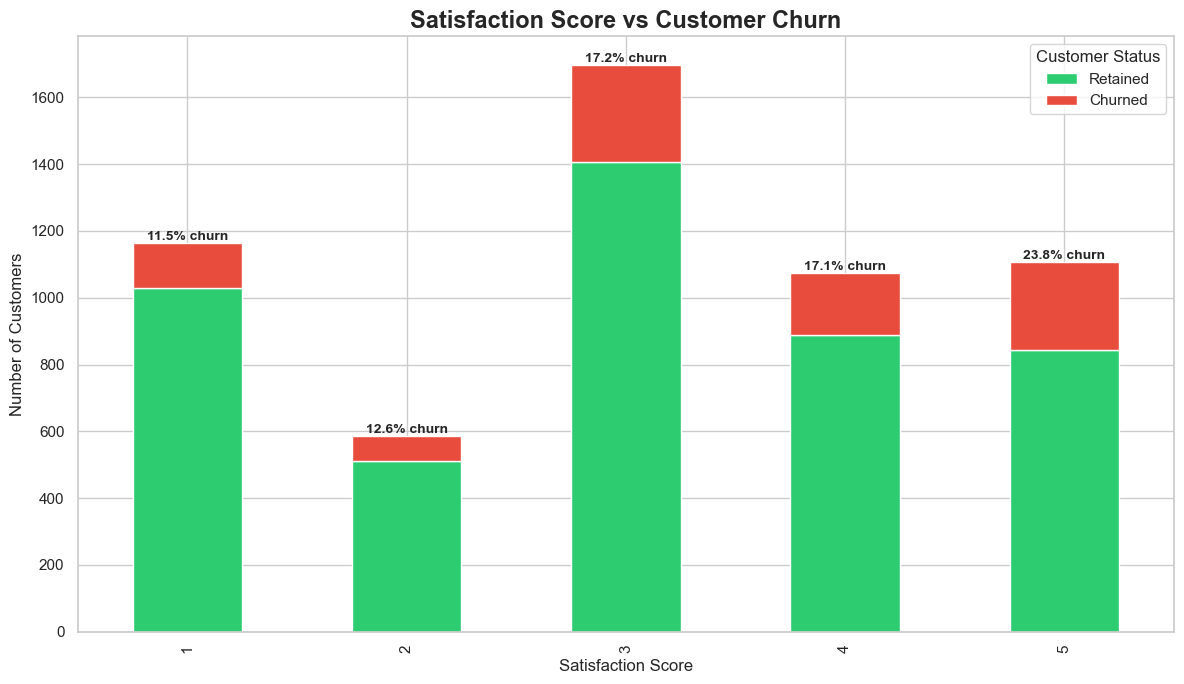

Highest churn rate: Satisfaction Score 5 (23.83%)
Lowest churn rate: Satisfaction Score 1 (11.51%)


In [8]:
# Create satisfaction versus churn count table
satisfaction_counts = pd.crosstab(
    df["SatisfactionScore"],
    df["Churn"]
).reindex(columns=[0, 1], fill_value=0)

# Rename columns
satisfaction_counts.columns = ["Retained", "Churned"]

# Calculate churn rate at each satisfaction level
satisfaction_churn_rate = (
    satisfaction_counts["Churned"] /
    satisfaction_counts.sum(axis=1) * 100
)

# Display churn rate by satisfaction score
satisfaction_summary = satisfaction_counts.copy()
satisfaction_summary["Churn Rate %"] = satisfaction_churn_rate

print("Churn Rate by Satisfaction Score:")
display(satisfaction_summary)

# Create stacked bar chart
ax = satisfaction_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    color=[RETAINED_COLOR, CHURN_COLOR]
)

# Add churn rate labels above each stack
for position, churn_rate in enumerate(satisfaction_churn_rate):

    total_customers = satisfaction_counts.iloc[position].sum()

    ax.text(
        position,
        total_customers,
        f"{churn_rate:.1f}% churn",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Satisfaction Score vs Customer Churn",
    fontsize=17,
    fontweight="bold"
)
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")
plt.legend(title="Customer Status")

plt.tight_layout()

# Save visualization
plt.savefig(
    f"{IMAGE_FOLDER}/satisfaction_vs_churn.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Identify highest and lowest churn satisfaction levels
highest_satisfaction_churn_level = satisfaction_churn_rate.idxmax()
highest_satisfaction_churn_rate = satisfaction_churn_rate.max()

lowest_satisfaction_churn_level = satisfaction_churn_rate.idxmin()
lowest_satisfaction_churn_rate = satisfaction_churn_rate.min()

print(
    f"Highest churn rate: Satisfaction Score "
    f"{highest_satisfaction_churn_level} "
    f"({highest_satisfaction_churn_rate:.2f}%)"
)

print(
    f"Lowest churn rate: Satisfaction Score "
    f"{lowest_satisfaction_churn_level} "
    f"({lowest_satisfaction_churn_rate:.2f}%)"
)

### Business Insight

Satisfaction should not automatically be assumed to cause churn.

The correct interpretation is based on the observed churn rates at each
satisfaction level.

If lower satisfaction levels consistently show higher churn, the business
should investigate service quality, customer support, product experience,
delivery experience, and post-purchase engagement.

## Section 5: Complaint vs Churn ⭐

Customer complaints are one of the most important potential churn signals.

We compare churn rates between:
- Customers who complained
- Customers who did not complain

We also calculate the churn-rate multiple:

**Complaint Churn Rate / Non-Complaint Churn Rate**

This tells us how much higher the observed churn rate is among customers
who complained.

COMPLAINT VS CHURN ANALYSIS
Churn Rate - Customers with Complaint    : 31.67%
Churn Rate - Customers without Complaint : 10.93%
Customers who complain are approximately 2.90x as likely to churn.


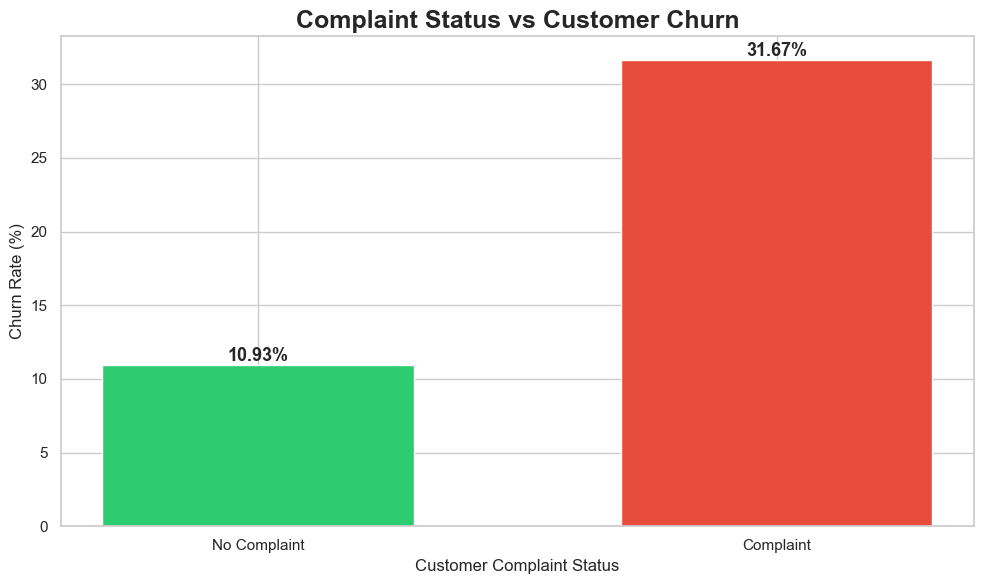

In [9]:
# Calculate churn rate for customers who complained
complaint_churn_rate = (
    df.loc[df["Complain"] == 1, "Churn"].mean() * 100
)

# Calculate churn rate for customers who did not complain
no_complaint_churn_rate = (
    df.loc[df["Complain"] == 0, "Churn"].mean() * 100
)

# Calculate the churn-rate multiple
complaint_churn_multiple = (
    complaint_churn_rate / no_complaint_churn_rate
)

# Print the results
print("=" * 65)
print("COMPLAINT VS CHURN ANALYSIS")
print("=" * 65)

print(
    f"Churn Rate - Customers with Complaint    : "
    f"{complaint_churn_rate:.2f}%"
)

print(
    f"Churn Rate - Customers without Complaint : "
    f"{no_complaint_churn_rate:.2f}%"
)

print(
    f"Customers who complain are approximately "
    f"{complaint_churn_multiple:.2f}x as likely to churn."
)

print("=" * 65)

# Create comparison dataframe
complaint_summary = pd.DataFrame({
    "Customer Group": [
        "No Complaint",
        "Complaint"
    ],
    "Churn Rate": [
        no_complaint_churn_rate,
        complaint_churn_rate
    ]
})

# Create highlight visualization
plt.figure(figsize=(10, 6))

bars = plt.bar(
    complaint_summary["Customer Group"],
    complaint_summary["Churn Rate"],
    color=[RETAINED_COLOR, CHURN_COLOR],
    width=0.6
)

# Add percentage labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

plt.title(
    "Complaint Status vs Customer Churn",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Customer Complaint Status")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()

# Save highlight chart
plt.savefig(
    f"{IMAGE_FOLDER}/complaint_vs_churn_highlight.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### ⭐ Business Insight

Complaint status should be treated as a major retention investigation area.

A substantially higher churn rate among customers who complain indicates that
complaints may be an important signal of customer dissatisfaction and potential
relationship failure.

However, this analysis shows **association, not causation**. A complaint may
occur because the customer was already experiencing other problems.

## Section 6: Tenure Analysis ⭐

Tenure is one of the most important variables in customer retention analysis.

Customers are divided into four lifecycle groups:

- 0–6 months
- 7–12 months
- 13–24 months
- 25+ months

The objective is to identify whether churn is concentrated among newer customers.

Churn Analysis by Tenure Group:


,Total_Customers,Churned_Customers,Churn Rate %
TenureGroup,,,
0-6 Months,2150,697,32.42
7-12 Months,1584,156,9.85
13-24 Months,1467,95,6.48
25+ Months,429,0,0.00


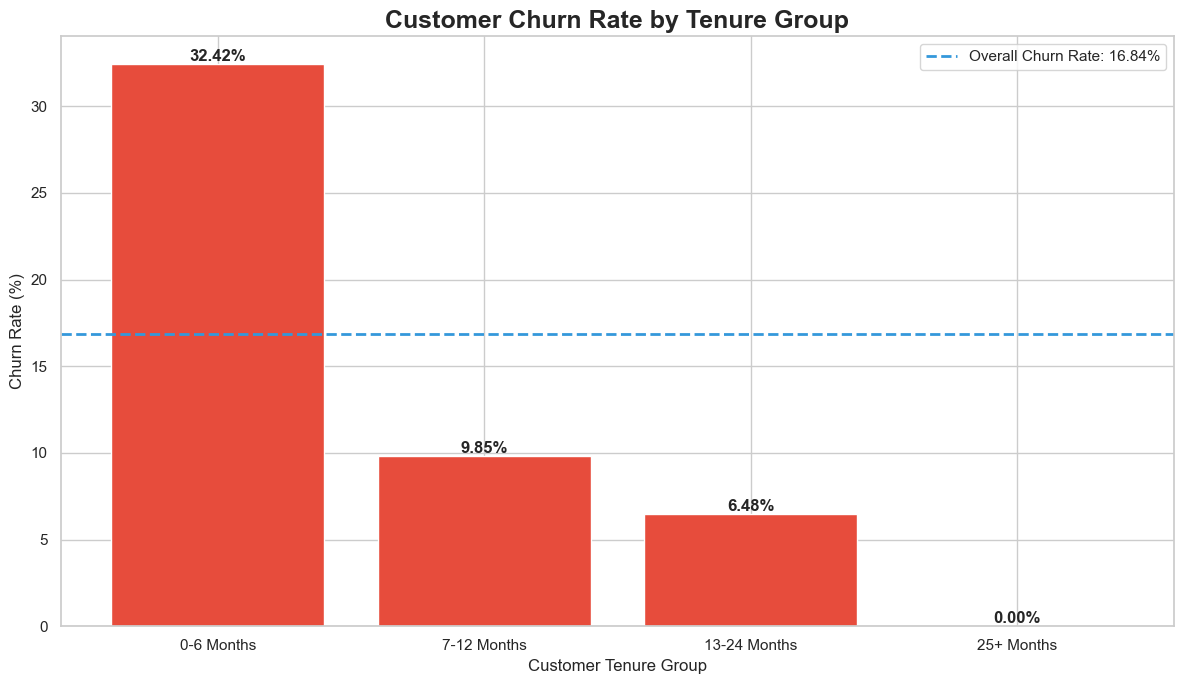

Highest churn tenure group: 0-6 Months (32.42%)


In [10]:
# Create tenure groups based on customer lifecycle stage
df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=[-np.inf, 6, 12, 24, np.inf],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25+ Months"
    ]
)

# Calculate churn count and total customers for each tenure group
tenure_summary = df.groupby(
    "TenureGroup",
    observed=False
)["Churn"].agg(
    Total_Customers="count",
    Churned_Customers="sum"
)

# Calculate churn rate
tenure_summary["Churn Rate %"] = (
    tenure_summary["Churned_Customers"] /
    tenure_summary["Total_Customers"] * 100
)

# Display tenure analysis
print("Churn Analysis by Tenure Group:")
display(tenure_summary)

# Create churn-rate visualization
plt.figure(figsize=(12, 7))

bars = plt.bar(
    tenure_summary.index.astype(str),
    tenure_summary["Churn Rate %"],
    color=CHURN_COLOR
)

# Add churn rate labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Add overall churn benchmark
overall_churn_rate = df["Churn"].mean() * 100

plt.axhline(
    overall_churn_rate,
    color="#3498DB",
    linestyle="--",
    linewidth=2,
    label=f"Overall Churn Rate: {overall_churn_rate:.2f}%"
)

plt.title(
    "Customer Churn Rate by Tenure Group",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Customer Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.legend()

plt.tight_layout()

# Save tenure chart
plt.savefig(
    f"{IMAGE_FOLDER}/tenure_group_churn.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Identify the highest-churn tenure group
highest_tenure_churn_group = tenure_summary["Churn Rate %"].idxmax()
highest_tenure_churn_rate = tenure_summary["Churn Rate %"].max()

print(
    f"Highest churn tenure group: "
    f"{highest_tenure_churn_group} "
    f"({highest_tenure_churn_rate:.2f}%)"
)

### ⭐ Business Insight

The tenure analysis answers an important retention question:

**Does the company lose customers primarily during the early lifecycle?**

If the 0–6 month group has the highest churn rate, the business should focus
on early-life retention strategies such as onboarding, first-order experience,
customer education, proactive support, and early engagement campaigns.

## Section 7: Correlation Matrix

Correlation analysis helps identify numerical variables that have the strongest
linear relationship with the Churn variable.

The heatmap uses only numerical variables.

Important:

Correlation does not prove causation. It is used here to prioritize variables
for deeper business investigation.

Numerical Variables Most Correlated with Churn:


,Correlation with Churn
Tenure,-0.34
DaySinceLastOrder,-0.16
CashbackAmount,-0.15
NumberOfDeviceRegistered,0.11
SatisfactionScore,0.11
WarehouseToHome,0.07
NumberOfAddress,0.04
OrderCount,-0.02
HourSpendOnApp,0.02
OrderAmountHikeFromlastYear,-0.01


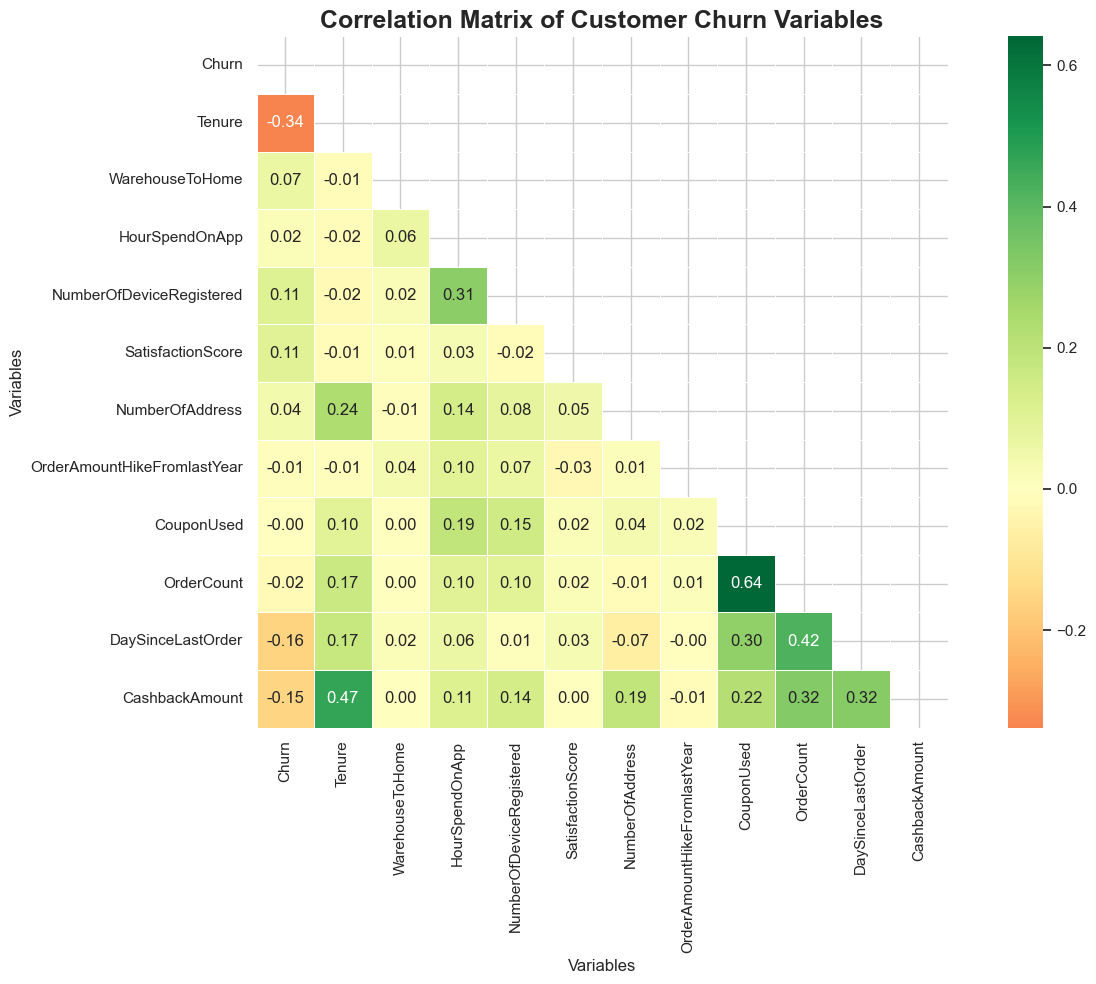

In [11]:
# Select numerical columns for correlation analysis
correlation_columns = [
    "Churn",
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount"
]

# Calculate correlation matrix
correlation_matrix = df[correlation_columns].corr()

# Extract correlation with Churn
churn_correlations = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

print("Numerical Variables Most Correlated with Churn:")
display(churn_correlations.to_frame("Correlation with Churn"))

# Create mask for upper triangle
upper_triangle_mask = np.triu(
    np.ones_like(correlation_matrix, dtype=bool)
)

# Create heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    mask=upper_triangle_mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Matrix of Customer Churn Variables",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Variables")
plt.ylabel("Variables")

plt.tight_layout()

# Save correlation heatmap
plt.savefig(
    f"{IMAGE_FOLDER}/correlation_matrix_churn.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Business Insight

The correlation matrix provides a quick screening mechanism for numerical
churn drivers.

Variables with stronger absolute correlations deserve additional investigation,
but correlation alone should not be interpreted as proof that a variable causes
customers to churn.

## Section 8: Churn by Multiple Factors

Single-variable analysis can hide important segment interactions.

This section investigates:

1. Gender + Marital Status
2. City Tier + Preferred Payment Mode

The objective is to identify smaller customer segments where churn may be
substantially different from the overall customer population.

Churn Rate by Gender + Marital Status:


,Gender,MaritalStatus,Churn Rate %
5,Male,Single,28.13
2,Female,Single,24.80
3,Male,Divorced,15.20
0,Female,Divorced,13.79
4,Male,Married,12.57
1,Female,Married,9.82


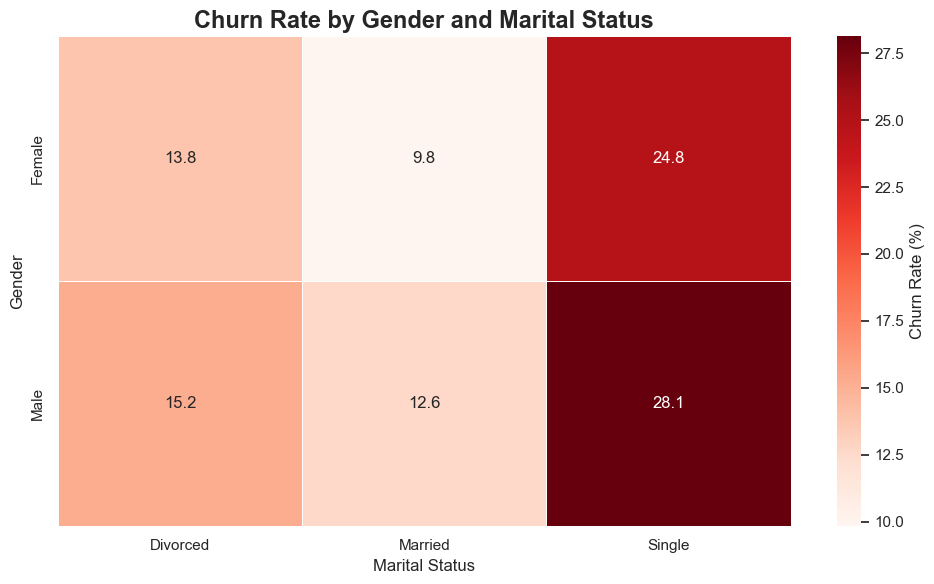

In [12]:
# Calculate churn rate by Gender and MaritalStatus
gender_marital_churn = (
    df.groupby(
        ["Gender", "MaritalStatus"],
        observed=False
    )["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn Rate %")
)

# Display the segment-level churn rates
print("Churn Rate by Gender + Marital Status:")
display(
    gender_marital_churn.sort_values(
        "Churn Rate %",
        ascending=False
    )
)

# Pivot data for heatmap
gender_marital_heatmap = gender_marital_churn.pivot(
    index="Gender",
    columns="MaritalStatus",
    values="Churn Rate %"
)

# Create heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    gender_marital_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title(
    "Churn Rate by Gender and Marital Status",
    fontsize=17,
    fontweight="bold"
)
plt.xlabel("Marital Status")
plt.ylabel("Gender")

plt.tight_layout()

# Save chart
plt.savefig(
    f"{IMAGE_FOLDER}/gender_marital_churn_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### City Tier + Payment Mode

This analysis combines geography with payment preference.

A high-churn combination may indicate a segment-specific customer experience,
payment friction, or market-level issue that is hidden when the variables are
analyzed separately.

Churn Rate by City Tier + Preferred Payment Mode:


,CityTier,PreferredPaymentMode,Churn Rate %
6,2,Cash on Delivery,50.00
11,3,Cash on Delivery,30.83
15,3,UPI,27.59
9,2,UPI,24.56
10,3,CC,23.08
14,3,E wallet,22.80
1,1,Cash on Delivery,21.86
0,1,CC,21.70
13,3,Debit Card,20.00
5,2,CC,16.67


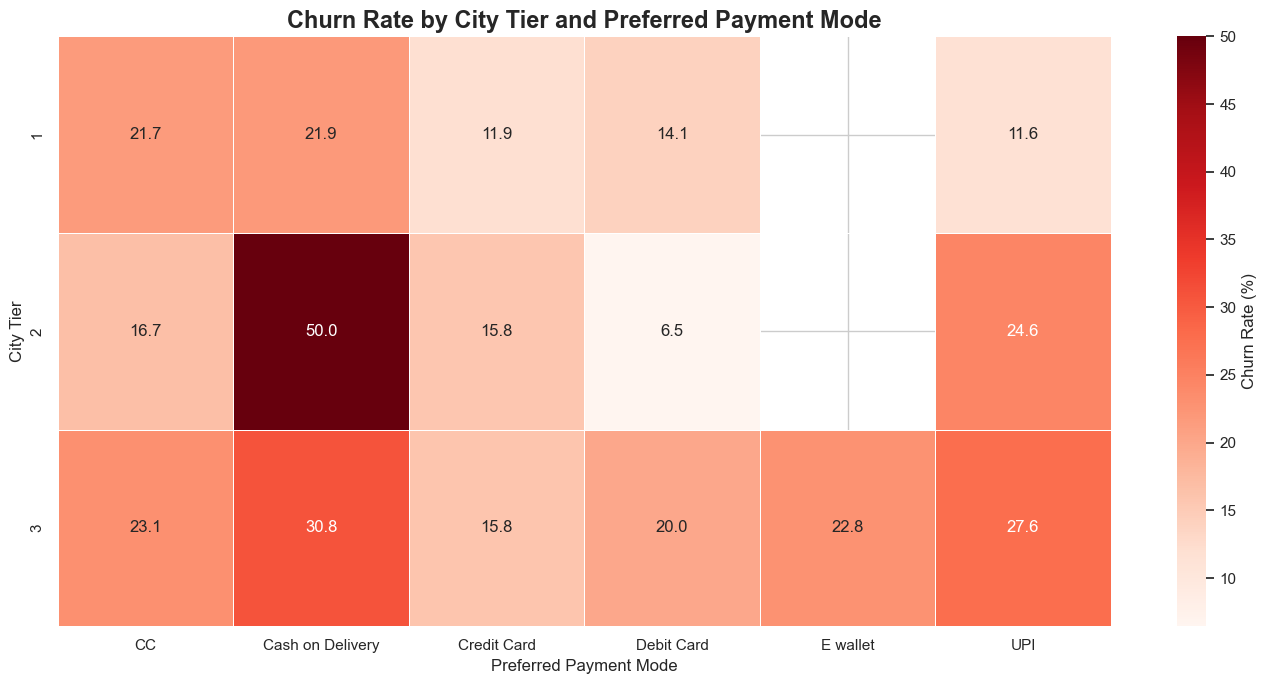

In [13]:
# Calculate churn rate by CityTier and PreferredPaymentMode
city_payment_churn = (
    df.groupby(
        ["CityTier", "PreferredPaymentMode"],
        observed=False
    )["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn Rate %")
)

# Display the segment analysis
print("Churn Rate by City Tier + Preferred Payment Mode:")
display(
    city_payment_churn.sort_values(
        "Churn Rate %",
        ascending=False
    )
)

# Create pivot table for heatmap
city_payment_heatmap = city_payment_churn.pivot(
    index="CityTier",
    columns="PreferredPaymentMode",
    values="Churn Rate %"
)

# Create heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    city_payment_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title(
    "Churn Rate by City Tier and Preferred Payment Mode",
    fontsize=17,
    fontweight="bold"
)
plt.xlabel("Preferred Payment Mode")
plt.ylabel("City Tier")

plt.tight_layout()

# Save chart
plt.savefig(
    f"{IMAGE_FOLDER}/city_payment_churn_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Section 9: Interactive Plotly Charts

Interactive charts are useful for exploring customer behavior at an individual
customer level.

Two interactive visualizations are created:

1. Tenure vs Cashback Amount
2. City Tier → Gender → Churn sunburst

These charts demonstrate interactive analytical storytelling.

In [14]:
# Create a copy for interactive visualization
plotly_data = df.copy()

# Convert Churn into readable labels
plotly_data["Churn Status"] = plotly_data["Churn"].map({
    0: "Retained",
    1: "Churned"
})

# Create interactive scatter plot
scatter_figure = px.scatter(
    plotly_data,
    x="Tenure",
    y="CashbackAmount",
    color="Churn Status",
    color_discrete_map={
        "Retained": RETAINED_COLOR,
        "Churned": CHURN_COLOR
    },
    hover_data=[
        "CustomerID",
        "OrderCount",
        "SatisfactionScore",
        "DaySinceLastOrder"
    ],
    title="Interactive Analysis: Tenure vs Cashback Amount",
    labels={
        "Tenure": "Customer Tenure (Months)",
        "CashbackAmount": "Cashback Amount",
        "Churn Status": "Customer Status"
    }
)

# Improve chart dimensions
scatter_figure.update_layout(
    width=1100,
    height=650,
    template="plotly_white"
)

# Display interactive chart
scatter_figure.show()

# Save interactive chart as HTML
scatter_figure.write_html(
    f"{IMAGE_FOLDER}/interactive_tenure_cashback.html"
)

### Interactive Sunburst

The sunburst visualizes the hierarchy:

**City Tier → Gender → Churn Status**

This makes it possible to drill down from broad geographic segments into
gender and then churn status.

In [15]:
# Create interactive sunburst chart
sunburst_figure = px.sunburst(
    plotly_data,
    path=[
        "CityTier",
        "Gender",
        "Churn Status"
    ],
    color="Churn Status",
    color_discrete_map={
        "Retained": RETAINED_COLOR,
        "Churned": CHURN_COLOR
    },
    title="Interactive Customer Churn: City Tier → Gender → Churn"
)

# Configure chart dimensions and layout
sunburst_figure.update_layout(
    width=1000,
    height=750,
    template="plotly_white"
)

# Display interactive chart
sunburst_figure.show()

# Save interactive chart as HTML
sunburst_figure.write_html(
    f"{IMAGE_FOLDER}/interactive_city_gender_churn_sunburst.html"
)

## Section 10: Statistical Test ⭐

### Business Question

Is there a statistically significant difference in customer tenure between
churned and retained customers?

### Hypotheses

**Null Hypothesis (H₀):**
There is no statistically significant difference in tenure between churned
and retained customers.

**Alternative Hypothesis (H₁):**
There is a statistically significant difference in tenure between churned
and retained customers.

We use an independent two-sample t-test because tenure is a numerical variable
and the two groups contain different customers.

Significance level:

**α = 0.05**

In [16]:
# Extract tenure values for retained customers
retained_tenure = df.loc[
    df["Churn"] == 0,
    "Tenure"
].dropna()

# Extract tenure values for churned customers
churned_tenure = df.loc[
    df["Churn"] == 1,
    "Tenure"
].dropna()

# Perform independent two-sample t-test
t_statistic, p_value = ttest_ind(
    churned_tenure,
    retained_tenure,
    equal_var=False
)

# Define significance level
alpha = 0.05

# Calculate group means
retained_tenure_mean = retained_tenure.mean()
churned_tenure_mean = churned_tenure.mean()

# Print statistical test results
print("=" * 70)
print("TENURE DIFFERENCE — INDEPENDENT T-TEST")
print("=" * 70)

print(f"Retained Mean Tenure : {retained_tenure_mean:.2f}")
print(f"Churned Mean Tenure  : {churned_tenure_mean:.2f}")
print(f"t-statistic          : {t_statistic:.4f}")
print(f"p-value              : {p_value:.6f}")
print(f"Significance Level   : {alpha}")

print("\nConclusion:")

if p_value < alpha:
    print(
        "We REJECT the null hypothesis — tenure significantly "
        "differs between churned and retained customers."
    )
else:
    print(
        "We FAIL TO REJECT the null hypothesis — there is not "
        "enough statistical evidence to conclude that tenure "
        "differs between churned and retained customers."
    )

print("=" * 70)

TENURE DIFFERENCE — INDEPENDENT T-TEST
Retained Mean Tenure : 11.40
Churned Mean Tenure  : 3.86
t-statistic          : -35.0876
p-value              : 0.000000
Significance Level   : 0.05

Conclusion:
We REJECT the null hypothesis — tenure significantly differs between churned and retained customers.


### Statistical Interpretation

If the p-value is below 0.05, the observed tenure difference is statistically
significant at the 5% significance level.

This does **not** mean tenure alone causes churn.

It means that the tenure distributions of churned and retained customers are
statistically different enough that the observed difference is unlikely to be
explained by random sampling variation alone.

## Section 11: Key Findings Summary

The final section converts the analytical results into concise business findings.

The values are calculated dynamically from the dataset, so the summary remains
accurate if the cleaned dataset is updated.

In [17]:
# Calculate percentage of churned customers with tenure below 6 months
churned_low_tenure_percentage = (
    (df.loc[df["Churn"] == 1, "Tenure"] <= 6).mean() * 100
)

# Find strongest positive numerical correlation with churn
positive_correlations = churn_correlations[
    churn_correlations > 0
]

if len(positive_correlations) > 0:
    strongest_positive_variable = positive_correlations.idxmax()
    strongest_positive_correlation = positive_correlations.max()
else:
    strongest_positive_variable = "None"
    strongest_positive_correlation = np.nan

# Find strongest negative numerical correlation with churn
negative_correlations = churn_correlations[
    churn_correlations < 0
]

if len(negative_correlations) > 0:
    strongest_negative_variable = negative_correlations.idxmin()
    strongest_negative_correlation = negative_correlations.min()
else:
    strongest_negative_variable = "None"
    strongest_negative_correlation = np.nan

# Identify highest churn demographic segment
highest_gender_segment = gender_churn_analysis["Churn Rate %"].idxmax()
highest_gender_churn = gender_churn_analysis["Churn Rate %"].max()

# Identify highest churn tenure group
highest_tenure_group = tenure_summary["Churn Rate %"].idxmax()
highest_tenure_group_rate = tenure_summary["Churn Rate %"].max()

# Identify highest churn cross-segment combination
highest_cross_segment = gender_marital_churn.loc[
    gender_marital_churn["Churn Rate %"].idxmax()
]

# Print formatted business summary
print("=" * 85)
print("                    TOP 5 CHURN DRIVERS IDENTIFIED")
print("=" * 85)

print(
    f"\n1. COMPLAINTS"
    f"\n   Customers with complaints: "
    f"{complaint_churn_rate:.2f}% churn"
    f"\n   Customers without complaints: "
    f"{no_complaint_churn_rate:.2f}% churn"
    f"\n   Complaint churn multiple: "
    f"{complaint_churn_multiple:.2f}x"
)

print(
    f"\n2. LOW TENURE"
    f"\n   {churned_low_tenure_percentage:.2f}% of churned customers "
    f"have tenure of 6 months or less."
    f"\n   Highest-churn tenure group: "
    f"{highest_tenure_group} ({highest_tenure_group_rate:.2f}%)"
)

print(
    f"\n3. NUMERICAL CHURN ASSOCIATION"
    f"\n   Strongest positive numerical relationship: "
    f"{strongest_positive_variable} "
    f"({strongest_positive_correlation:.3f})"
)

print(
    f"\n4. TENURE DIFFERENCE"
    f"\n   Retained mean tenure: "
    f"{retained_tenure_mean:.2f} months"
    f"\n   Churned mean tenure: "
    f"{churned_tenure_mean:.2f} months"
    f"\n   Statistical test p-value: "
    f"{p_value:.6f}"
)

print(
    f"\n5. HIGH-RISK CUSTOMER SEGMENT"
    f"\n   Highest Gender segment churn rate: "
    f"{highest_gender_segment} "
    f"({highest_gender_churn:.2f}%)"
    f"\n   Highest Gender + Marital Status combination:"
    f" {highest_cross_segment['Gender']} + "
    f"{highest_cross_segment['MaritalStatus']} "
    f"({highest_cross_segment['Churn Rate %']:.2f}%)"
)

print("\n" + "=" * 85)
print("BUSINESS INTERPRETATION")
print("=" * 85)

print(
    "\nThe analysis indicates that customer churn is not driven by a single "
    "customer characteristic. Instead, churn should be investigated through "
    "multiple dimensions including complaints, customer tenure, satisfaction, "
    "engagement, ordering behavior, and customer segments."
)

print(
    "\nThe strongest opportunities for retention analysis are customers with "
    "early tenure, customers who have submitted complaints, and customer "
    "segments whose observed churn rate is substantially above the overall "
    f"baseline of {overall_churn_rate:.2f}%."
)

print(
    "\nThese findings should be treated as analytical associations rather "
    "than causal conclusions. Further business investigation is required "
    "before implementing retention interventions."
)

print("\nNotebook 2 — Churn Deep Dive Analysis completed successfully.")

                    TOP 5 CHURN DRIVERS IDENTIFIED

1. COMPLAINTS
   Customers with complaints: 31.67% churn
   Customers without complaints: 10.93% churn
   Complaint churn multiple: 2.90x

2. LOW TENURE
   73.52% of churned customers have tenure of 6 months or less.
   Highest-churn tenure group: 0-6 Months (32.42%)

3. NUMERICAL CHURN ASSOCIATION
   Strongest positive numerical relationship: NumberOfDeviceRegistered (0.108)

4. TENURE DIFFERENCE
   Retained mean tenure: 11.40 months
   Churned mean tenure: 3.86 months
   Statistical test p-value: 0.000000

5. HIGH-RISK CUSTOMER SEGMENT
   Highest Gender segment churn rate: Male (17.73%)
   Highest Gender + Marital Status combination: Male + Single (28.13%)

BUSINESS INTERPRETATION

The analysis indicates that customer churn is not driven by a single customer characteristic. Instead, churn should be investigated through multiple dimensions including complaints, customer tenure, satisfaction, engagement, ordering behavior, and custome